In [33]:
# Import Required Libraries

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Model evaluation metrics
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

# Statistical analysis
from scipy import stats

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

#Improve the Appearance of Graphs
# Set visualization style
plt.style.use("seaborn-v0_8-darkgrid")

# Set default color palette
sns.set_palette("husl")

In [9]:
# 1. Load Auto MPG Dataset
vehicles = pd.read_csv('auto_mpg_synthetic_dataset.csv')
print("Dataset loaded successfully from URL!")

Dataset loaded successfully from URL!


In [10]:
# 2. Display the first five rows.
vehicles.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,25.6,4,240.8,144,2832,18.2,72,1,Car_001
1,34.4,8,411.6,140,2344,15.9,79,1,Car_002
2,12.9,6,392.2,210,4301,14.5,76,3,Car_003
3,19.9,5,322.4,170,3244,16.9,76,1,Car_004
4,39.9,4,253.9,79,1500,17.4,70,1,Car_005


In [11]:
# 3. Display the dataset shape.
vehicles.shape

(300, 9)

In [14]:
# 4. Display info() .
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           300 non-null    float64
 1   cylinders     300 non-null    int64  
 2   displacement  300 non-null    float64
 3   horsepower    300 non-null    int64  
 4   weight        300 non-null    int64  
 5   acceleration  300 non-null    float64
 6   model_year    300 non-null    int64  
 7   origin        300 non-null    int64  
 8   car_name      300 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 21.2+ KB


In [15]:
# 5. Display describe() .
vehicles.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.0000,300.000000
mean,27.211000,5.196667,316.861333,153.580000,2796.476667,15.067667,76.0500,1.836667
std,7.564451,1.494020,73.708896,32.989969,678.251591,2.039490,3.5782,0.867466
min,8.000000,3.000000,158.100000,79.000000,1500.000000,9.800000,70.0000,1.000000
25%,21.500000,4.000000,258.975000,129.750000,2291.750000,13.600000,73.0000,1.000000
50%,27.850000,4.000000,295.750000,153.500000,2789.000000,15.100000,76.0000,2.000000
75%,32.425000,6.000000,362.350000,175.000000,3244.750000,16.400000,79.0000,3.000000
max,46.600000,8.000000,500.000000,239.000000,4955.000000,20.200000,82.0000,3.000000


In [ ]:
Questions
1. How many observations are in the dataset?
 - 300
2. Which column is the target variable?
 - the first column "mpg"
3. Which column contains text?
 - the last column "car_name"

In [ ]:
Exercise 2: Missing Values
1. Check for missing values.
2. If any exist, remove them.
3. Display the new dataset shape.

In [21]:
vehicles.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [ ]:
Questions
1. Which columns contain missing values?
 - there is no missing value columns
2. Why should missing values be handled before training?
 - to prevent errors b/c algorithms cannot handle null values
 - to prevent inaccurate predictions and data loss

In [ ]:
Exercise 3: Exploratory Data Analysis

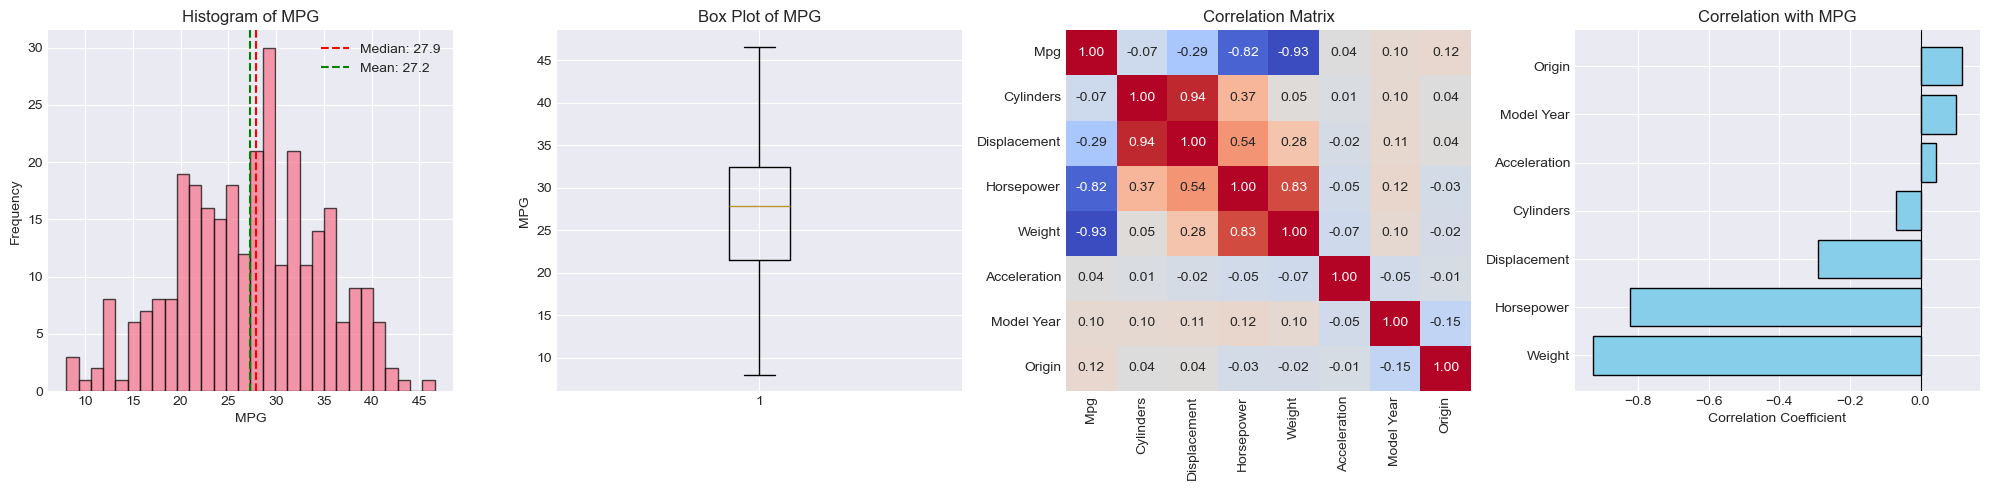

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Histogram of MPG

axes[0].hist(vehicles["mpg"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_title("Histogram of MPG")
axes[0].set_xlabel("MPG")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
    vehicles["mpg"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {vehicles['mpg'].median():.1f}",
)
axes[0].axvline(
    vehicles["mpg"].mean(),
    color="green",
    linestyle="--",
    label=f"Mean: {vehicles['mpg'].mean():.1f}",
)
axes[0].legend()

# 2. Box Plot of MPG 

axes[1].boxplot(vehicles["mpg"])
axes[1].set_title("Box Plot of MPG")
axes[1].set_ylabel("MPG")
axes[1].set_xticks([1])

# Data Prep for Correlations

numeric_df = vehicles.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# 3. Correlation Matrix (Heatmap)
# Cleaned axis tick labels to remove underscores and capitalize
clean_labels = [col.replace("_", " ").title() for col in corr_matrix.columns]

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[2],
    cbar=False,
    xticklabels=clean_labels,
    yticklabels=clean_labels,
)
axes[2].set_title("Correlation Matrix")

# 4. Correlation Bar Chart (Perfected)

mpg_corr = corr_matrix["mpg"].drop("mpg").sort_values()

# Clean up raw feature names for the bar chart y-axis
clean_bar_labels = [idx.replace("_", " ").title() for idx in mpg_corr.index]

axes[3].barh(
    clean_bar_labels, mpg_corr.values, color="skyblue", edgecolor="black"
)
axes[3].axvline(0, color="black", linestyle="-", linewidth=0.8)
axes[3].set_title("Correlation with MPG")
axes[3].set_xlabel("Correlation Coefficient")

plt.tight_layout()
plt.show()

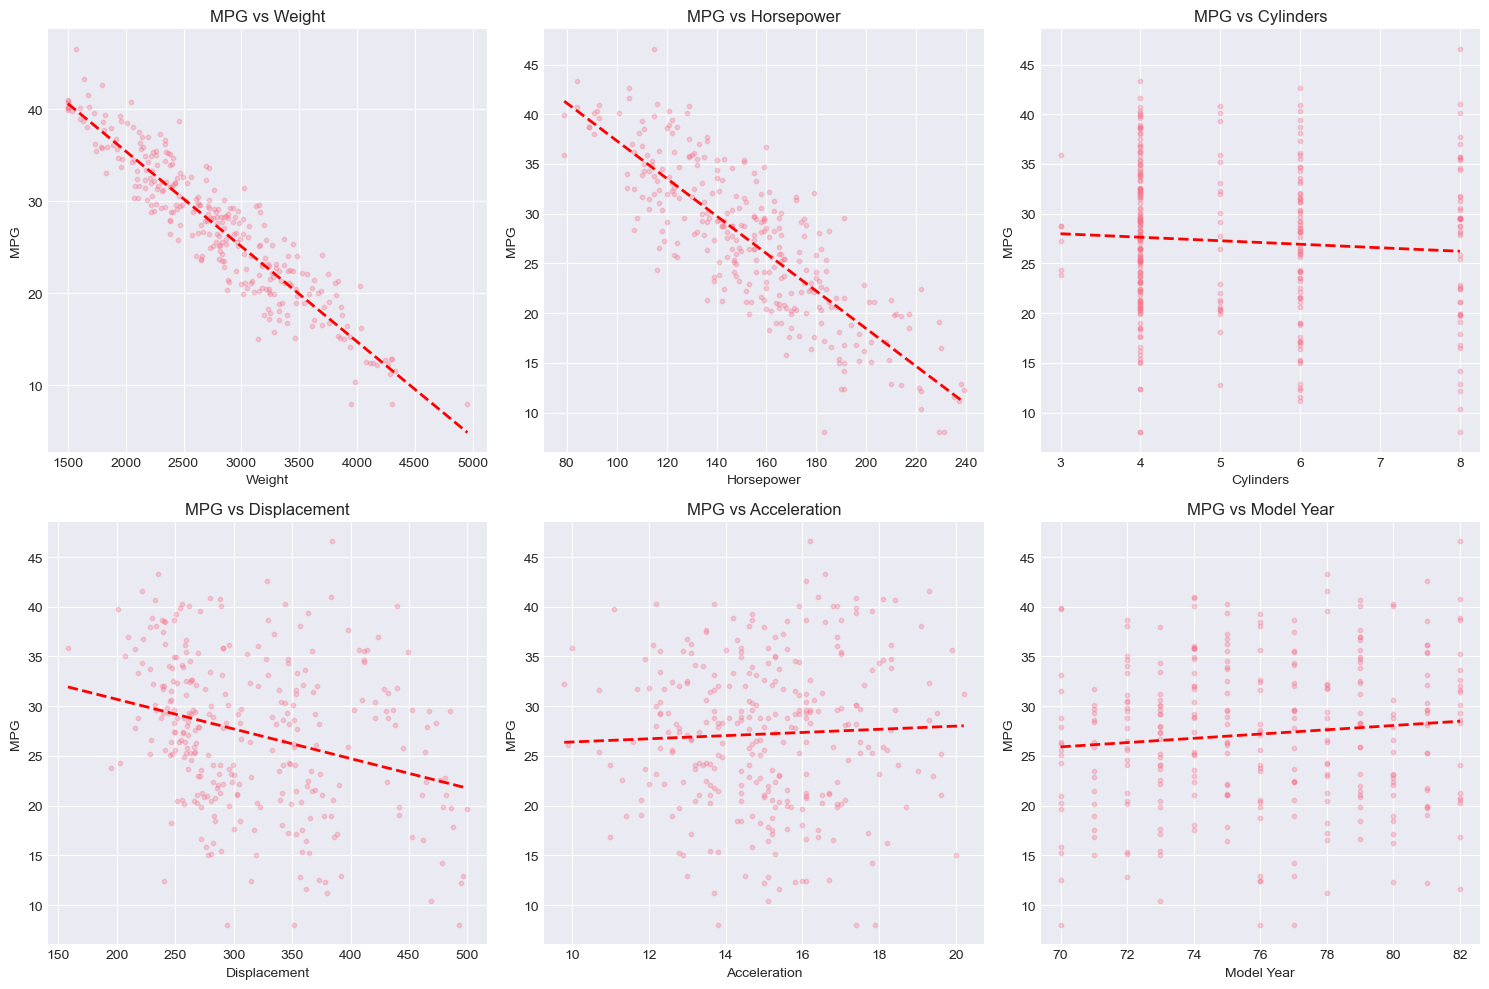

In [32]:
# Scatter Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = [
    "weight",
    "horsepower",
    "cylinders",
    "displacement",
    "acceleration",
    "model_year",
]

for index, feature in enumerate(features):
    row = index // 3
    column = index % 3

    axes[row, column].scatter(
        vehicles[feature], vehicles["mpg"], alpha=0.3, s=10
    )

    # Clean up the string formatting for the plots
    clean_label = feature.replace("_", " ").title()

    axes[row, column].set_title(f"MPG vs {clean_label}")
    axes[row, column].set_xlabel(clean_label)
    axes[row, column].set_ylabel("MPG")

    # Add linear trend line
    z = np.polyfit(vehicles[feature], vehicles["mpg"], 1)
    p = np.poly1d(z)

    axes[row, column].plot(
        vehicles[feature].sort_values(),
        p(vehicles[feature].sort_values()),
        "r--",
        linewidth=2,
    )

plt.tight_layout()
plt.show()

In [ ]:
For each scatter plot answer:
Is the relationship positive or negative?
 - its positive for acceleration and model year
Is it strong or weak?
 - its weak for Acceleration for others mostly strong and moderate
Are there any outliers?
 - yes